In [1]:
from anndata import AnnData
from scipy.stats import pearsonr, spearmanr, wilcoxon

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("../")
import auxiliary_breast as auxbr
import auxiliary_plot as auxpl
figsize = auxpl.figsize
fontsize = auxpl.fontsize

## Loading ST dataset

In [2]:
id_list = {'CID4290': 'ER_0',
           'CID4535': 'ER_1',
           'CID44971': 'TNBC_3',
           'CID4465': 'TNBC_2',
           '1142243F': 'TNBC_0',
           '1160920F': 'TNBC_1'}
sample_list = id_list.keys()
adatas_raw = dict() # input of STAN
adatas_stan = dict() # output of STAN
for sample in sample_list:
    adatas_raw[id_list[sample]] = sc.read_h5ad("results_breast/breast_st_qc/{}.h5ad".format(sample))
    adatas_stan[id_list[sample]] = sc.read_h5ad("results_breast/breast_st_stan/{}.h5ad".format(sample))

In [3]:
adatas_tfa = dict()
for sample in id_list.values():
    adata_stan = adatas_stan[sample]
    adata_tfa = AnnData(
        X = adata_stan.obsm['tfa_stan'],
        obs = adata_stan.obs,
        obsm = {name: obj for (name, obj) in adata_stan.obsm.items() if "tf" not in name},
        layers = {name: obj for (name, obj) in adata_stan.obsm.items() if "tf" in name})
    adata_tfa.uns = adata_stan.uns
    sc.pp.scale(adata_tfa)
    sc.tl.rank_genes_groups(adata_tfa, groupby='pathology', method="wilcoxon")
    adatas_tfa[sample] = adata_tfa

## TF activity score by sample by pathology

Figure 3B

In [4]:
dfs_tf_pat = auxpl.make_pat_tf_dataframe(adatas_tfa)
dfs_tf_pat_diff = dict()
for sample in id_list.values():
    adata_tfa = adatas_tfa[sample]
    df = dfs_tf_pat[sample]
    df['diff'] = 0
    mat = adata_tfa.to_df()
    for i in df.index:
        tf = df['TF'][i]
        pat = df['Pathology'][i]
        x = mat.loc[adata_tfa.obs['pathology']==pat, tf].mean(numeric_only=True)
        y = mat.loc[adata_tfa.obs['pathology']!=pat, tf].mean(numeric_only=True)
        df['diff'][i] = x-y
    dfs_tf_pat_diff[sample] = df

In [5]:
df_tf_pat = pd.concat(dfs_tf_pat, ignore_index=True)

In [6]:
def plot_heatmap(data, title):
    x = "TF"
    y = 'sample'
    tfs = data.pivot(index=y, columns=x, values="TFa").dropna(axis=1).columns.to_list()
    data = data.query("TF in @tfs")
    data.to_csv('../df2plot_inR/breast_{}.csv'.format(title))
    print(len(tfs))

    data[x] = data[x].astype("category")
    data[y] = data[y].astype("category")
    x_lab = data[x].cat.categories
    y_lab = data[y].cat.categories

    f = sns.clustermap(data.pivot(index=y, columns=x, values="TFa").dropna(axis=1),figsize=(0.1,0.1), cmap='PiYG')
    x_lab = x_lab[f.dendrogram_col.reordered_ind]
    y_lab = y_lab[f.dendrogram_row.reordered_ind]
    print(x_lab)
    print(y_lab)

    data[x] = data[x].cat.reorder_categories(x_lab)
    data[y] = data[y].cat.reorder_categories(y_lab)
    data = data.sort_values([x, y])
    
    data["TFa\n(scaled)"]=data["TFa"].clip(-1, 1)

    figsize = 0.2
    plt.figure(figsize=(figsize*len(x_lab), figsize*len(y_lab)), dpi=300)
    plt.rc('font', size=fontsize/1.8) 
    ax = sns.scatterplot(data=data,x=x, y=y, palette="PiYG_r", hue="TFa\n(scaled)", size="-log(p_adj)")
    plt.legend(bbox_to_anchor=(1,1), loc='upper left', columnspacing=0.5, handletextpad=0, frameon=False, 
               fontsize=fontsize/2, ncols=2)

    ax.set_xticklabels(x_lab,rotation = 90)
    ax.set_xlim(-0.5, -0.5+len(x_lab))
    ax.set_ylim(-0.5, -0.5+len(y_lab))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title)

36
30
Index(['ZKSCAN1', 'BCL6', 'KLF10', 'MXI1', 'ELK1', 'JUN', 'VDR', 'NFATC1',
       'TEAD4', 'HSF2', 'MEF2C', 'KLF4', 'TP63', 'ELK4', 'PBX3', 'EBF1',
       'GTF2I', 'NR2F2', 'SPDEF', 'MAX', 'FLI1', 'KLF5', 'CREB1', 'GABPA',
       'NR3C1', 'MAZ', 'NFYB', 'SPI1', 'JUND', 'YY1'],
      dtype='object')
Index(['ER_0', 'TNBC_2', 'ER_1', 'TNBC_1', 'TNBC_0', 'TNBC_3'], dtype='object')


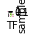

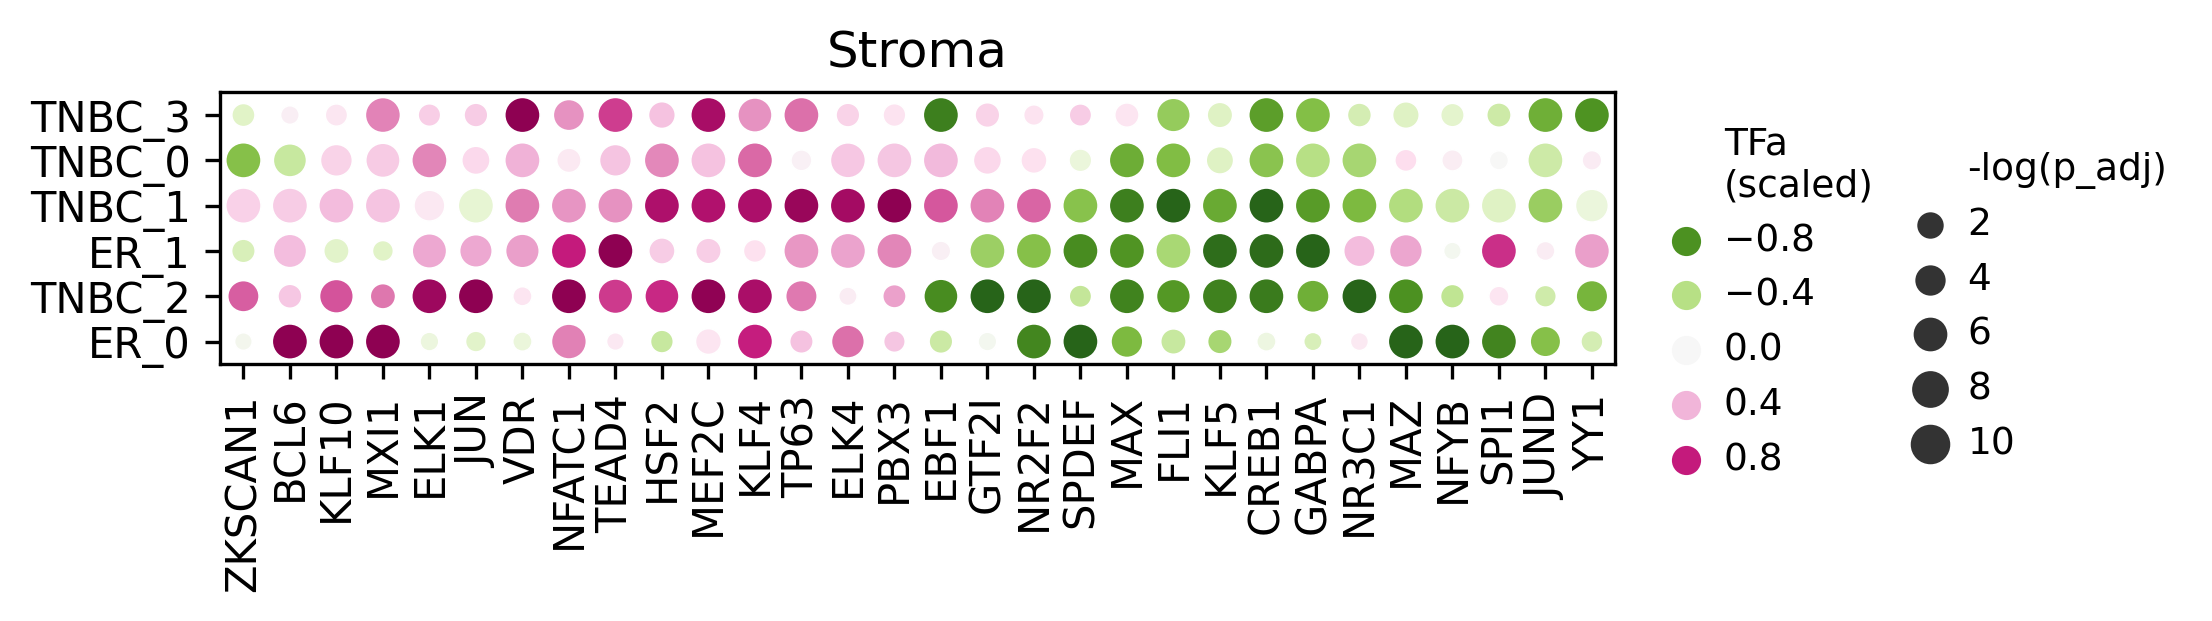

In [7]:
df_stroma = df_tf_pat.query("Pathology == 'Stroma'")
tfs = list()
n = 3
for sample in id_list.values():
    adata_tfa = adatas_tfa[sample]
    categories = adata_tfa.obs['pathology'].cat.categories
    for i in range(n):
        for j, cat in enumerate(categories):
            if cat=='Stroma':
                tfs.append(adata_tfa.uns['rank_genes_groups']['names'][i][j])
    for i in range(1,n+1):
        for j, cat in enumerate(categories):
            if cat=='Stroma':
                tfs.append(adata_tfa.uns['rank_genes_groups']['names'][-i][j])
print(len(tfs))
df_filtered = df_stroma.query("TF in @tfs")
plot_heatmap(df_filtered, 'Stroma')

22
22
Index(['ZKSCAN1', 'IRF4', 'TFAP4', 'IRF1', 'YY1', 'BACH2', 'EBF1', 'FOXP3',
       'RFX3', 'STAT2', 'GTF2I', 'MAZ', 'NFYB', 'NR2F2', 'JUND', 'NR3C1',
       'KLF5', 'GABPA', 'FLI1', 'SPDEF', 'CREB1', 'MAX'],
      dtype='object')
Index(['TNBC_0', 'TNBC_1', 'ER_1', 'TNBC_3'], dtype='object')


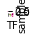

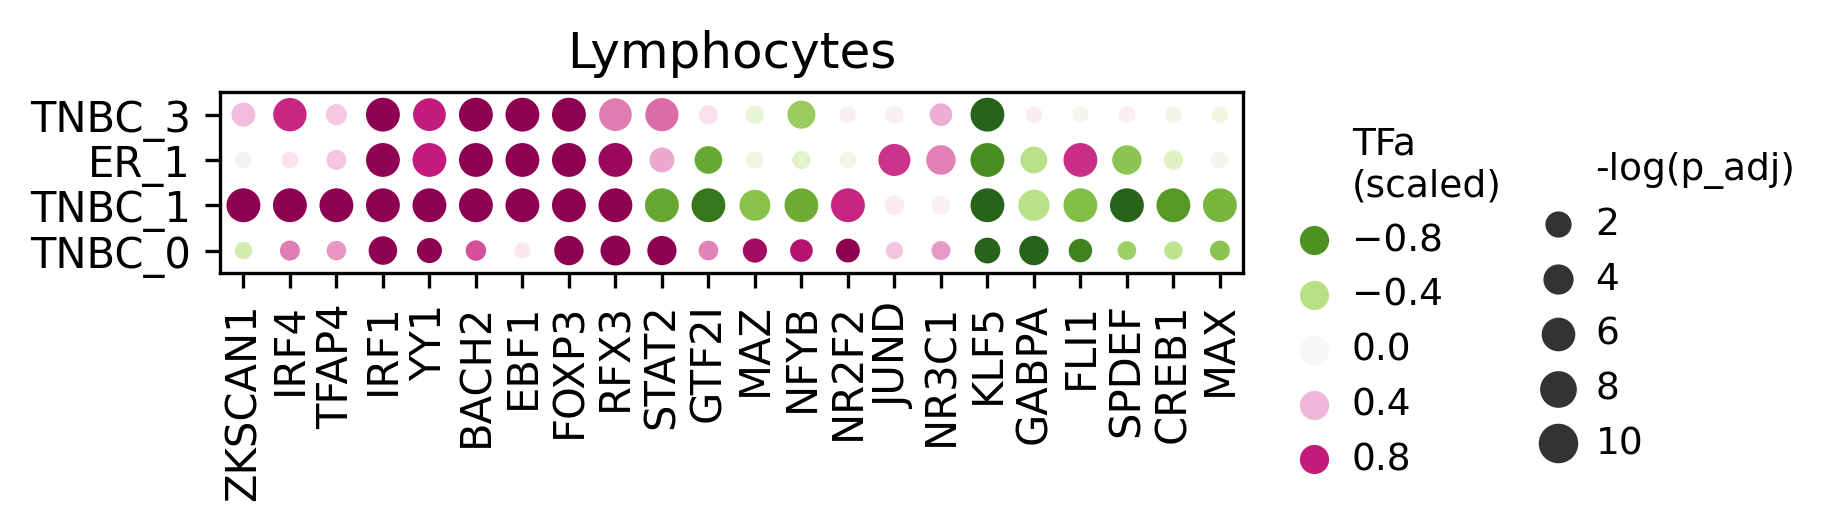

In [8]:
df_lymph = df_tf_pat.query("Pathology == 'Lymphocytes'")
tfs = list()
n = 3
for sample in id_list.values():
    adata_tfa = adatas_tfa[sample]
    categories = adata_tfa.obs['pathology'].cat.categories
    for i in range(n):
        for j, cat in enumerate(categories):
            if cat=='Lymphocytes':
                tfs.append(adata_tfa.uns['rank_genes_groups']['names'][i][j])
    for i in range(1,n+1):
        for j, cat in enumerate(categories):
            if cat=='Stroma':
                tfs.append(adata_tfa.uns['rank_genes_groups']['names'][-i][j])
print(len(set(tfs)))

df_filtered = df_lymph.query("TF in @tfs")
plot_heatmap(df_filtered, 'Lymphocytes')

19
19
Index(['FOXM1', 'E2F1', 'MAX', 'SPDEF', 'CREB1', 'KLF5', 'FLI1', 'GABPA',
       'JUND', 'NR2F2', 'NFYB', 'EBF1', 'YY1', 'ZKSCAN1', 'SPIB', 'MAZ',
       'NR3C1', 'FOSL1', 'GTF2I'],
      dtype='object')
Index(['ER_0', 'TNBC_1', 'TNBC_0', 'TNBC_2'], dtype='object')


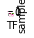

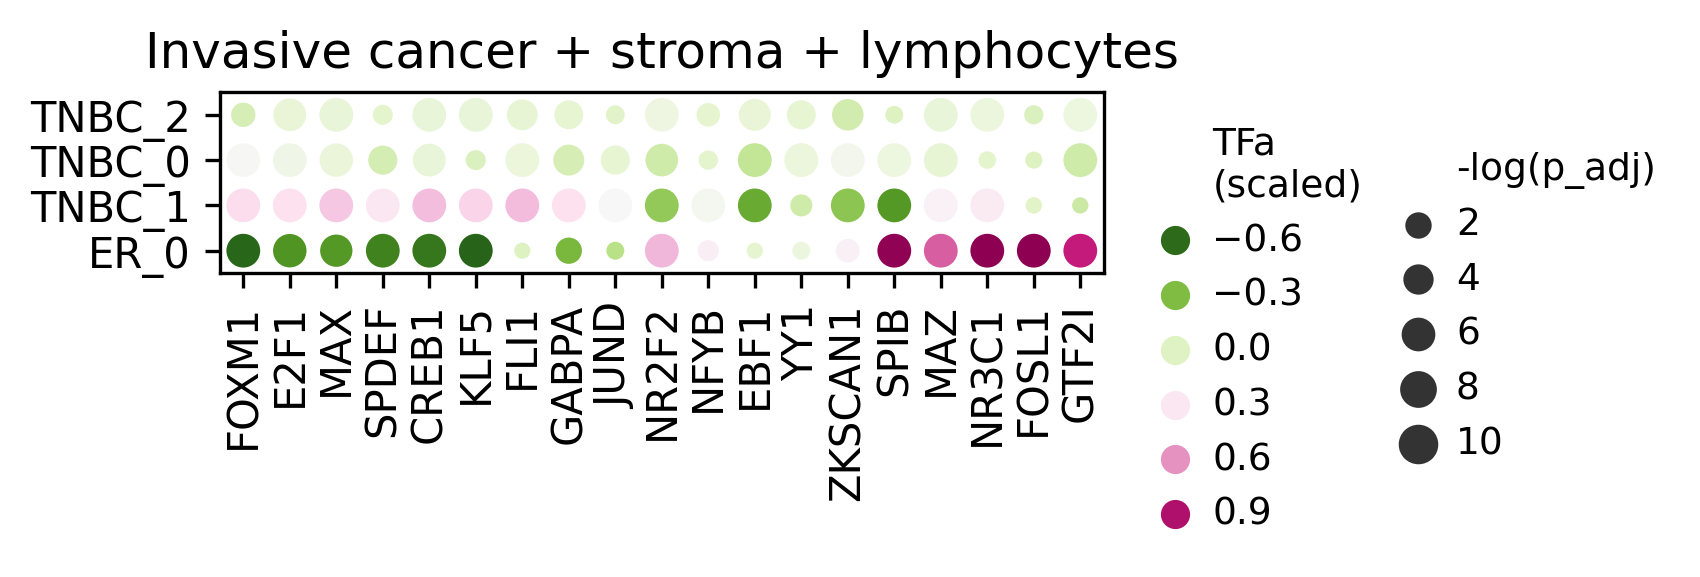

In [9]:
df_ic = df_tf_pat.query("Pathology == 'Invasive cancer + stroma + lymphocytes'")

tfs = list()
n = 3
for sample in id_list.values():
    adata_tfa = adatas_tfa[sample]
    categories = adata_tfa.obs['pathology'].cat.categories
    for i in range(n):
        for j, cat in enumerate(categories):
            if cat=='Invasive cancer + stroma + lymphocytes':
                tfs.append(adata_tfa.uns['rank_genes_groups']['names'][i][j])
    for i in range(1,n+1):
        for j, cat in enumerate(categories):
            if cat=='Stroma':
                tfs.append(adata_tfa.uns['rank_genes_groups']['names'][-i][j])
print(len(set(tfs)))

df_filtered = df_ic.query("TF in @tfs")
plot_heatmap(df_filtered, 'Invasive cancer + stroma + lymphocytes')

Figure 3C

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


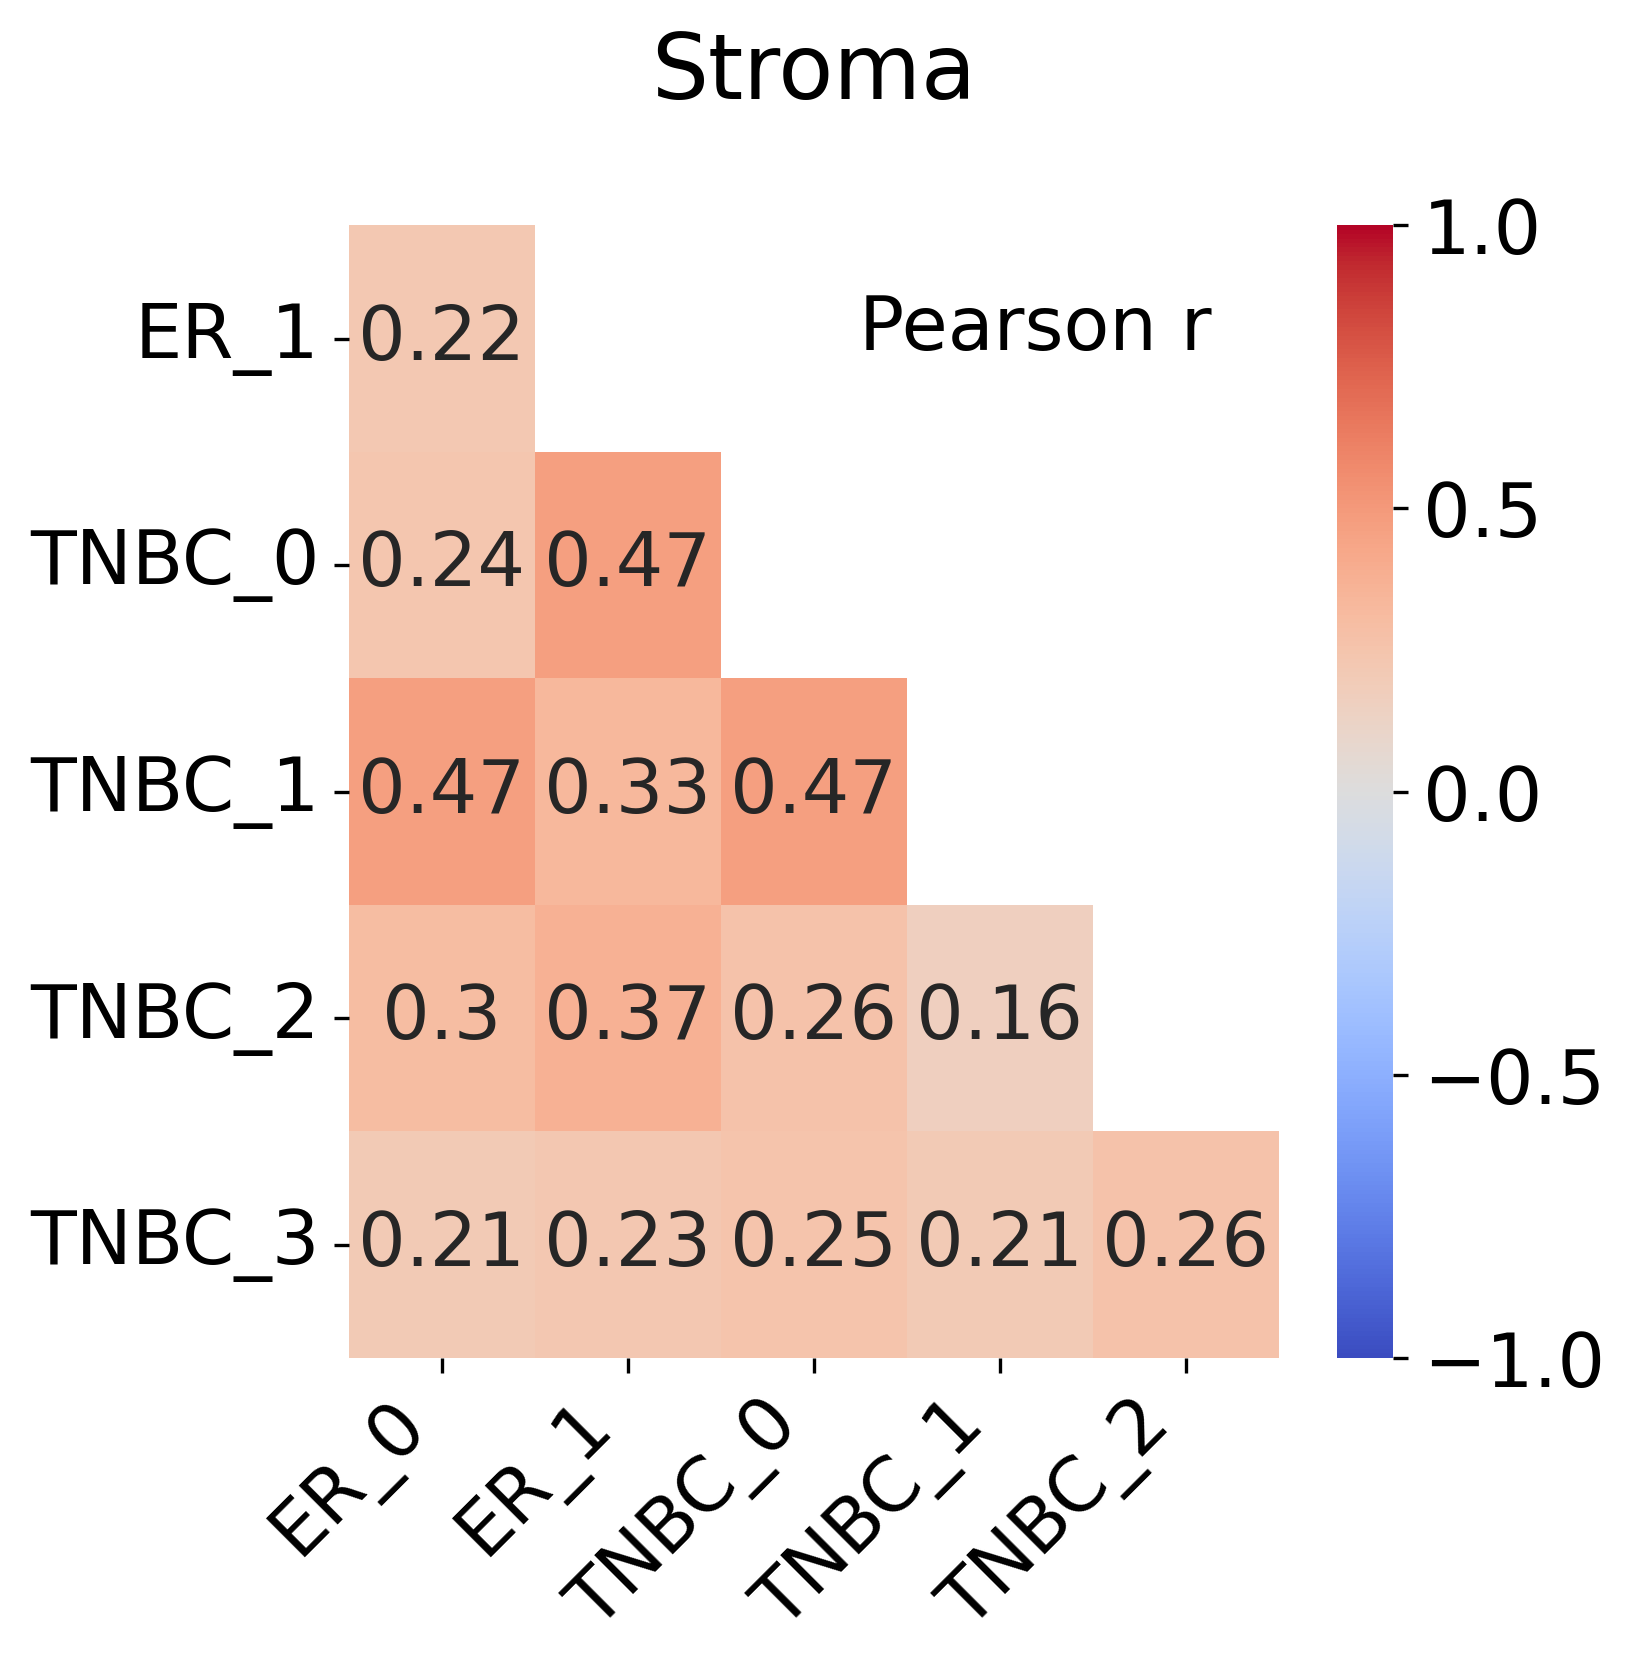

In [10]:
auxpl.plot_heatmap_correlation(df_stroma, "Stroma\n")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


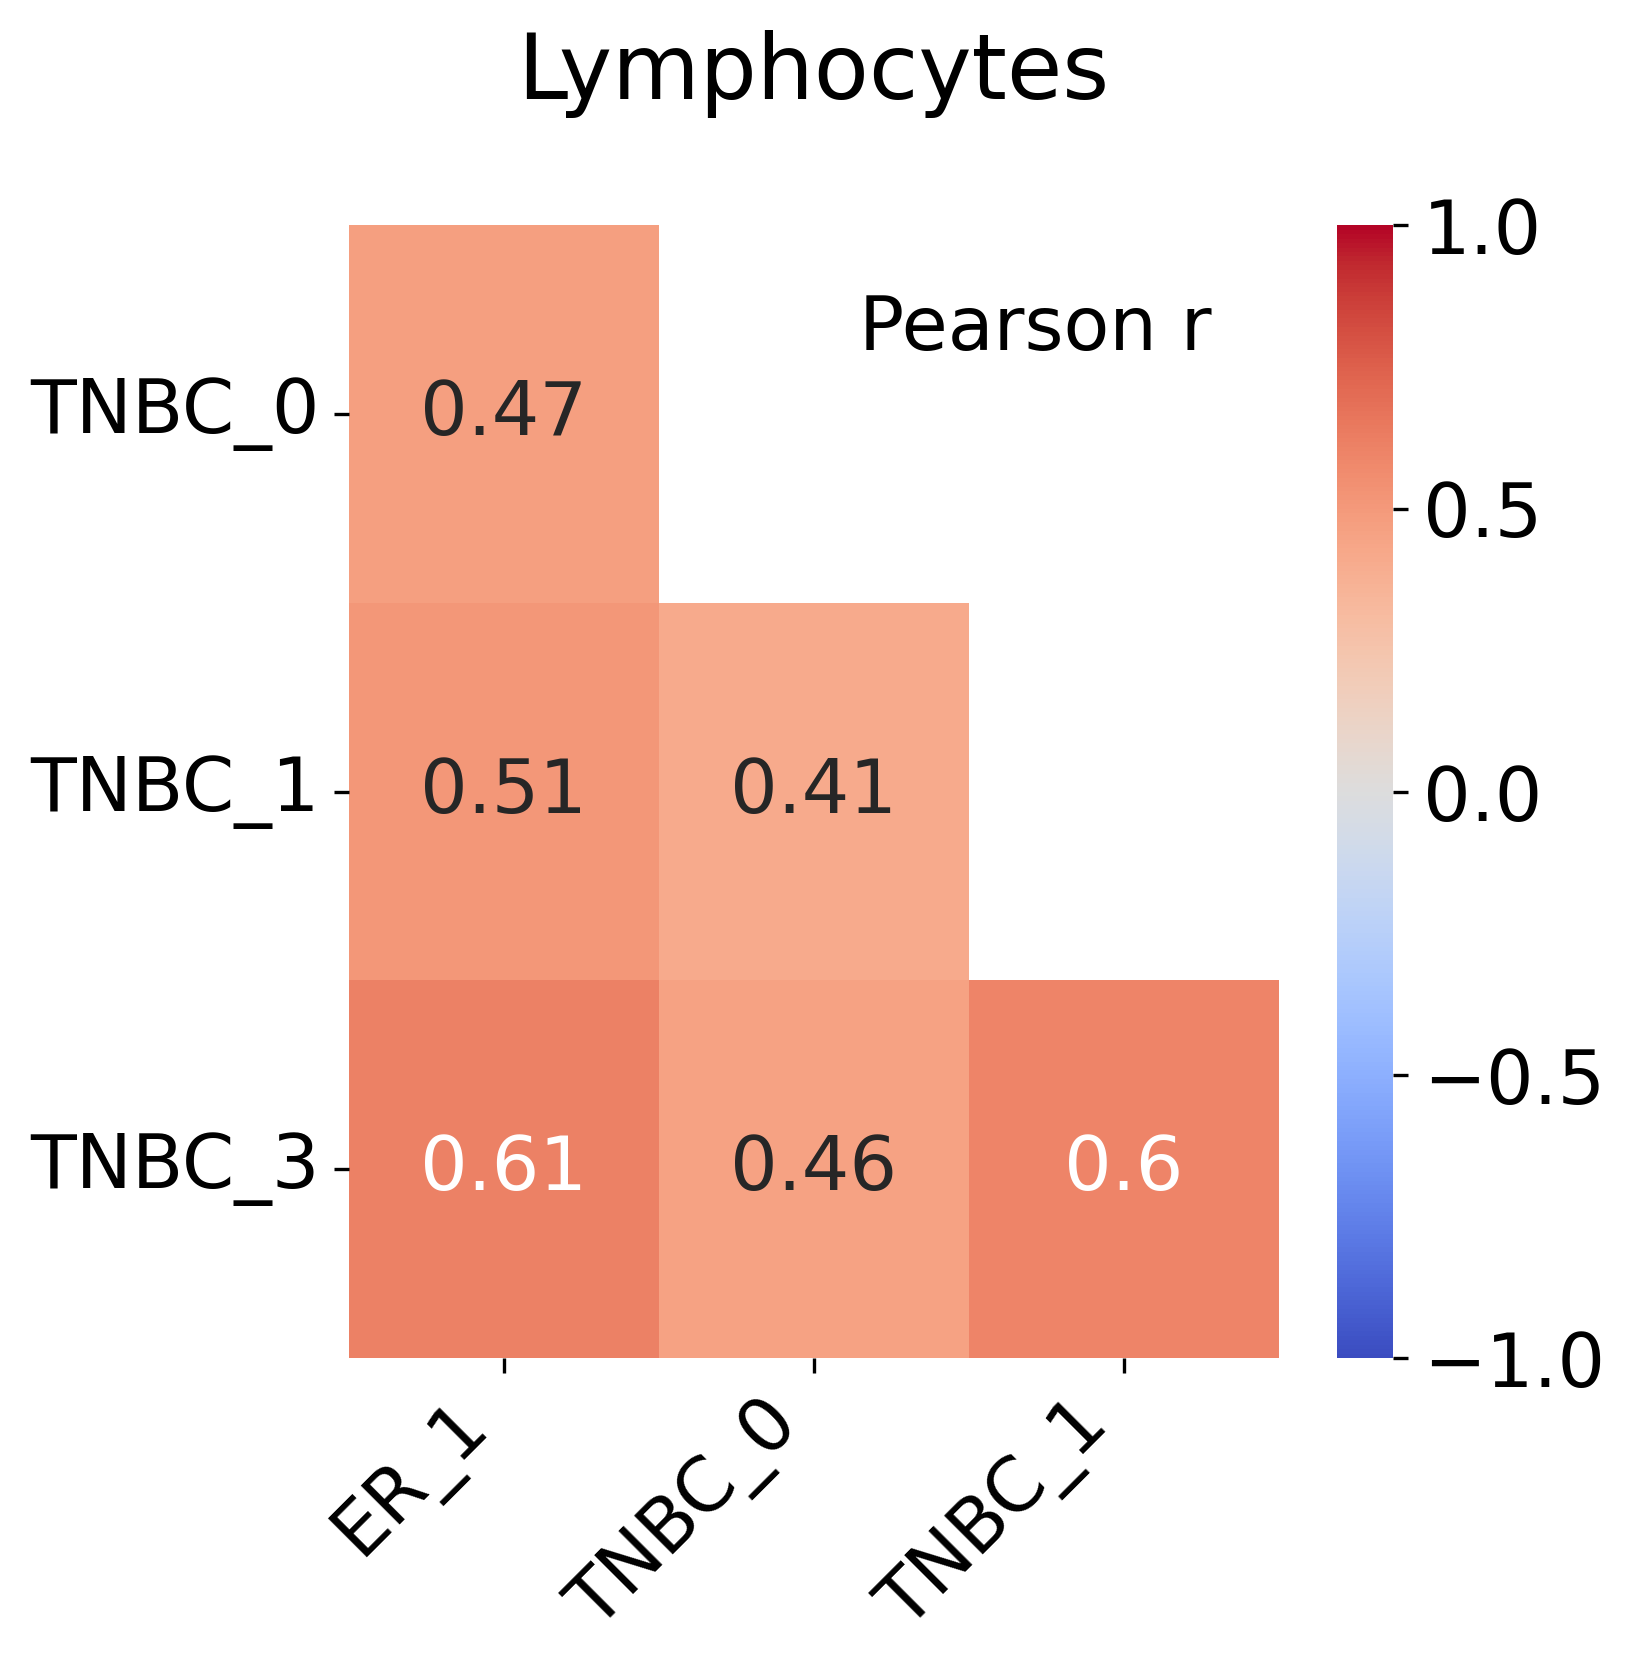

In [11]:
auxpl.plot_heatmap_correlation(df_lymph, "Lymphocytes\n")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


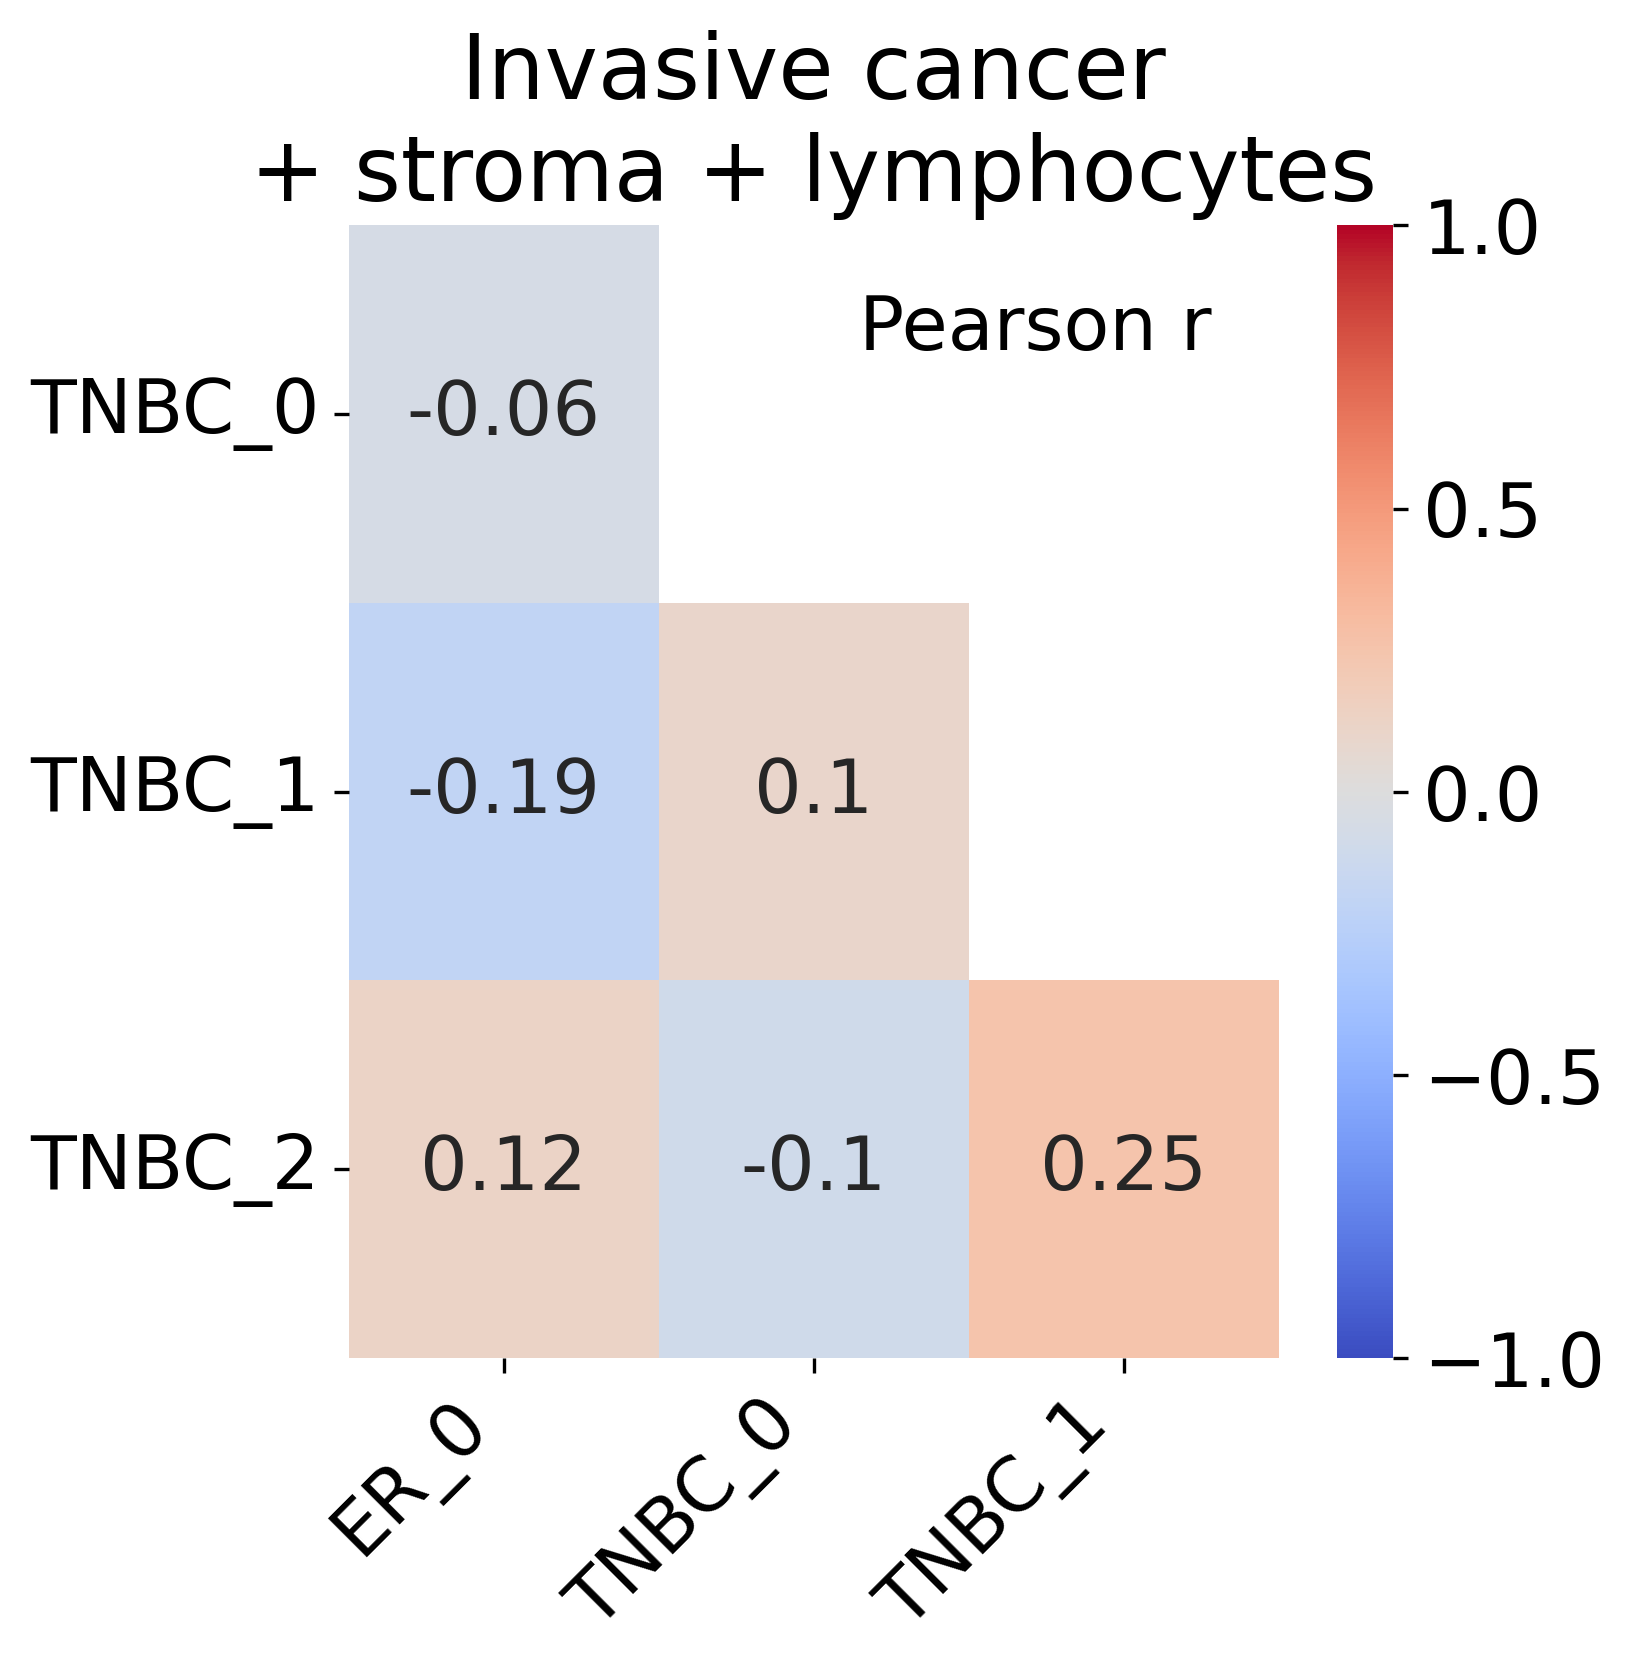

In [12]:
auxpl.plot_heatmap_correlation(df_ic, "Invasive cancer\n+ stroma + lymphocytes")

## TF activity score by pathology by sample
Figure 3D and Figure S4

In [13]:
dfs_tf_pat_top = dict()
for sample in id_list.values():
    adata_tfa = adatas_tfa[sample]
    categories = adatas_tfa[sample].obs['pathology'].cat.categories
    
    if len(categories)>3:
         top_tfs = [ x for sub in adata_tfa.uns['rank_genes_groups']['names'][:3] for x in sub] + [ x for sub in adata_tfa.uns['rank_genes_groups']['names'][-3:] for x in sub] 
    else:
        top_tfs = [ x for sub in adata_tfa.uns['rank_genes_groups']['names'][:5] for x in sub] + [ x for sub in adata_tfa.uns['rank_genes_groups']['names'][-5:] for x in sub] 
    
    df = dfs_tf_pat_diff[sample].query("TF in @top_tfs")
    df['TF'] = df['TF'].astype("category").cat.remove_unused_categories()
    dfs_tf_pat_top[sample] = df

Dotplots will be generated in R.

In [14]:
for sample in id_list.values():
    df = dfs_tf_pat_diff[sample]
    df.to_csv('../df2plot_inR/breast_tf_by_pathology_{}.csv'.format(sample))
    print(sample)
    auxbr.dendrogram_order(df)

ER_0
Index(['MAZ', 'NR2F2', 'SPI1', 'ETV5', 'NFYB', 'KLF3', 'EHF', 'FOXD2', 'GMEB2',
       'SETDB1',
       ...
       'ELF2', 'ETV7', 'FOXP2', 'SP1', 'FOXO3', 'KMT2A', 'ATF3', 'BCL11A',
       'HOXA4', 'TP73'],
      dtype='object', length=209)
Index(['Stroma', 'Invasive cancer + stroma',
       'Invasive cancer + stroma + lymphocytes'],
      dtype='object')
ER_1
Index(['FLI1', 'GTF2B', 'E2F6', 'EGR2', 'E2F2', 'GATA6', 'LEF1', 'SP2', 'ETS1',
       'HOXB13',
       ...
       'EGR1', 'ZBTB33', 'IRF4', 'STAT4', 'MYC', 'PAX5', 'AR', 'HNF4G', 'MZF1',
       'ZNF217'],
      dtype='object', length=218)
Index(['Invasive cancer + adipose tissue + lymphocytes', 'Adipose tissue',
       'Invasive cancer', 'Invasive cancer + lymphocytes', 'Lymphocytes',
       'Stroma'],
      dtype='object')
TNBC_3
Index(['JUND', 'MEF2C', 'HSF2', 'BACH1', 'AR', 'NFYA', 'NFAT5', 'NFATC1',
       'STAT5A', 'SIX5',
       ...
       'ESR1', 'ATF3', 'GLI2', 'HES1', 'USF2', 'ELF1', 'IRF3', 'FOXO3',
       'EOMES